<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%202/Week_2_Lecture_2_New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=1E44Sw8-RG0) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%202/DL4CV_Week02_Part02.pdf)

In [1]:
# Week 2, Lecture 2: From Edges to Blobs and Corners
from IPython.display import HTML, display

VIDEO_ID = "1E44Sw8-RG0"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 2, Lecture 2: From Edges to Blobs and Corners

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§2.2 Blob and Corner Detection**.

**What you will learn**

- Detect **blobs** with the Laplacian of Gaussian.
- Read the local **autocorrelation surface** and classify a window as flat, edge or corner.
- Use the **eigenvalues** of the second-moment matrix to make that classification precise.
- Implement the **Harris corner detector** and compare the common cornerness measures.
- Test how the detector behaves under **rotation and scale**.

**Contents**
1. From edge pixels to line segments
2. The Laplacian of Gaussian
3. LoG as a blob detector
4. Flat, edge, corner: the autocorrelation surface
5. Eigenvalues classify the window
6. The Harris corner detector
7. Cornerness measures and variants
8. Properties: rotation and scale

**How to run**  Runs on Colab or a local Jupyter, CPU only. Every image is bundled with `scikit-image`, so nothing is downloaded. Run the setup cell first, then go top to bottom.

## Review

The previous lecture produced Canny edges. This lecture moves to second-order structure (the Laplacian of Gaussian and **blobs**) and to **corners** (the Harris detector).

One tool recurs throughout: the eigen-analysis of a local $2 \times 2$ matrix. We meet it three times, for the orientation of a line, the shape of a blob, and the cornerness of a window. Its eigenvalues describe how strongly a quantity varies along two orthogonal directions.

## Setup

Everything uses images bundled with `scikit-image`, so the notebook runs offline. The helper `second_moment_eigs` builds the per-pixel second moment matrix and its eigenvalues once, since sections 5 to 8 all reuse it.

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage import data, util, color
from skimage.transform import rotate
from skimage.feature import blob_log, corner_harris, corner_peaks, peak_local_max

np.random.seed(0)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['image.cmap']     = 'gray'
plt.rcParams['figure.dpi']     = 85

def load_gray(image):
    return color.rgb2gray(image) if image.ndim == 3 else util.img_as_float(image)

def show(ax, im, title='', cmap='gray'):
    ax.imshow(im, cmap=cmap); ax.set_title(title); ax.axis('off')

def second_moment_eigs(Ix, Iy, sigma_w):
    # Gaussian-weighted second moment matrix entries a, b, c and its eigenvalues lam1 >= lam2
    a = ndi.gaussian_filter(Ix * Ix, sigma_w)
    b = ndi.gaussian_filter(Ix * Iy, sigma_w)
    c = ndi.gaussian_filter(Iy * Iy, sigma_w)
    tmp  = np.sqrt(((a - c) / 2)**2 + b**2)
    lam1 = (a + c) / 2 + tmp
    lam2 = (a + c) / 2 - tmp
    return a, b, c, lam1, lam2

## 1. From edge pixels to line segments

One use of Canny edges is grouping connected edge pixels into straight line segments. Given the pixel coordinates $(x, y)$ of an edgelet with mean $(\mu_x, \mu_y)$, form the **second moment matrix**

$$
M = \begin{bmatrix}
\sum (x - \mu_x)^2 & \sum (x - \mu_x)(y - \mu_y) \\
\sum (x - \mu_x)(y - \mu_y) & \sum (y - \mu_y)^2
\end{bmatrix},
\qquad [\,\mathbf{v}, \lambda\,] = \mathrm{eig}(M).
$$

The eigenvectors give the principal axes of the point cloud and the eigenvalues give its spread along them:

- **orientation** $\;\theta = \tan^{-1}(\mathbf{v}_1)\;$ from the larger eigenvector
- **straightness** $\;\lambda_2 / \lambda_1\;$ (near $0$ means a thin, straight segment; near $1$ means a round cluster)

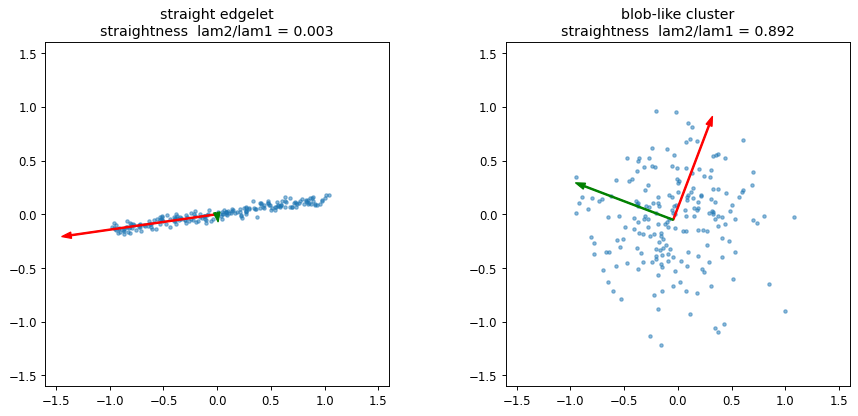

In [3]:
def moment_matrix(pts):
    d = pts - pts.mean(0)
    M = (d.T @ d) / len(pts)
    lam, V = np.linalg.eigh(M)              # ascending
    return M, lam[::-1], V[:, ::-1]         # return larger eigenvalue first

t = np.linspace(-1, 1, 200)
sets = {
    'straight edgelet':  np.c_[t, 0.15*t] + 0.03*np.random.randn(200, 2),
    'blob-like cluster': 0.40*np.random.randn(200, 2),
}

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
for a, (name, pts) in zip(ax, sets.items()):
    M, lam, V = moment_matrix(pts)
    mu = pts.mean(0)
    a.scatter(pts[:, 0], pts[:, 1], s=8, alpha=0.5)
    for k in range(2):                      # principal axes scaled by sqrt(eigenvalue)
        vec = V[:, k] * np.sqrt(lam[k]) * 2.5
        a.arrow(mu[0], mu[1], vec[0], vec[1], color='r' if k == 0 else 'g',
                width=0.012, head_width=0.06, length_includes_head=True)
    a.set_title(f'{name}\nstraightness  lam2/lam1 = {lam[1]/lam[0]:.3f}')
    a.set_aspect('equal'); a.set_xlim(-1.6, 1.6); a.set_ylim(-1.6, 1.6)
plt.tight_layout(); plt.show()

## 2. The Laplacian of Gaussian

The orientation-free second derivative is the **Laplacian**

$$
\nabla^2 f = \frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partial y^2}.
$$

Each second partial has a discrete form

$$
\frac{\partial^2 f}{\partial x^2} = f(x{+}1, y) + f(x{-}1, y) - 2 f(x, y),
\qquad
\frac{\partial^2 f}{\partial y^2} = f(x, y{+}1) + f(x, y{-}1) - 2 f(x, y),
$$

and their sum collapses to a single $3 \times 3$ kernel

$$
\nabla^2 f = f(x{+}1, y) + f(x{-}1, y) + f(x, y{+}1) + f(x, y{-}1) - 4 f(x, y)
\;\;\Longrightarrow\;\;
\begin{bmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{bmatrix}.
$$

The bare Laplacian amplifies noise, so we smooth with a Gaussian first. The combined operator is the **Laplacian of Gaussian** (LoG), $\nabla^2 (f * g)$.

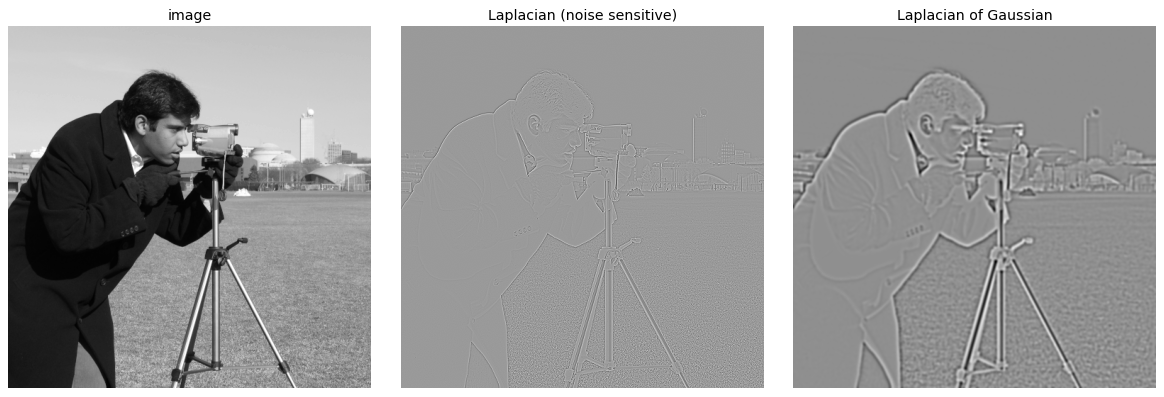

In [4]:
cam = load_gray(data.camera())
laplacian_k = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], float)

lap = ndi.convolve(cam, laplacian_k)        # bare Laplacian
log = ndi.gaussian_laplace(cam, sigma=2)    # Laplacian of Gaussian

fig, ax = plt.subplots(1, 3, figsize=(14, 4.6))
show(ax[0], cam, 'image')
show(ax[1], lap, 'Laplacian (noise sensitive)')
show(ax[2], log, 'Laplacian of Gaussian')
plt.tight_layout(); plt.show()

## 3. LoG as a blob detector

The LoG kernel is circularly symmetric, so convolution measures how well a local region matches a radially symmetric bump. A **blob** of radius $r$ produces the strongest response at the matching scale

$$
\sigma \approx \frac{r}{\sqrt{2}}, \qquad \text{detected radius} = \sigma \sqrt{2}.
$$

Searching across scales $\sigma$ and keeping the response peak performs **automatic scale selection**. Below, blobs of different sizes are each found at their own scale.

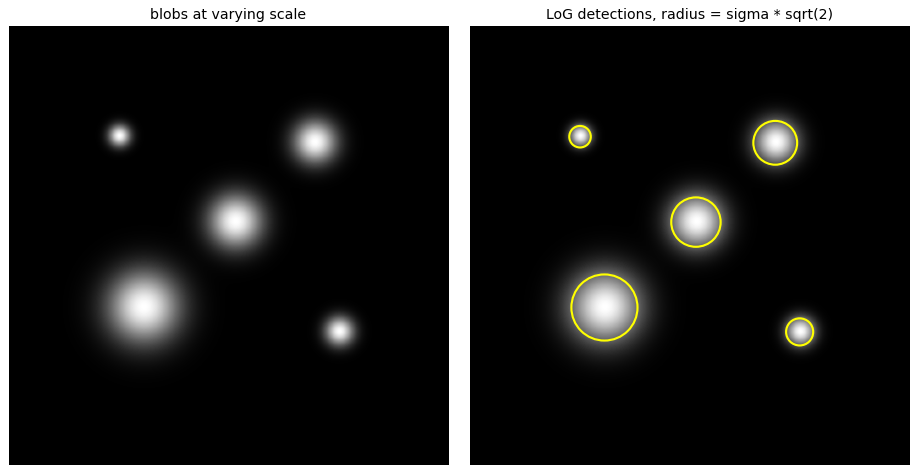

In [5]:
H = W = 360
yy, xx = np.mgrid[0:H, 0:W]
planted = [(90, 90, 6), (95, 250, 12), (160, 185, 15), (230, 110, 20), (250, 270, 8)]

blobs = np.zeros((H, W))
for cy, cx, s in planted:
    blobs += np.exp(-((yy - cy)**2 + (xx - cx)**2) / (2 * s**2))
blobs /= blobs.max()

# blob_log searches scales and returns (y, x, sigma) per detection
detections = blob_log(blobs, min_sigma=3, max_sigma=24, num_sigma=14, threshold=0.06)

fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
show(ax[0], blobs, 'blobs at varying scale')
show(ax[1], blobs, 'LoG detections, radius = sigma * sqrt(2)')
for y, x, s in detections:
    ax[1].add_patch(plt.Circle((x, y), s * np.sqrt(2), color='yellow', fill=False, lw=1.8))
plt.tight_layout(); plt.show()

## 4. Flat, edge, corner: the autocorrelation surface

To find corners, ask how a small window changes when shifted by $\Delta u$. The **autocorrelation** is the weighted sum of squared differences

$$
E_{AC}(\Delta u) = \sum_{x, y} w(x, y) \, \big[\, I(p + \Delta u) - I(p) \,\big]^2 .
$$

A first-order Taylor expansion $I(p + \Delta u) \approx I(p) + \nabla I(p)\, \Delta u$ turns this into a quadratic form

$$
E_{AC}(\Delta u) \approx \Delta u^\top A \, \Delta u,
\qquad
A = w * \begin{bmatrix} I_x^2 & I_x I_y \\ I_x I_y & I_y^2 \end{bmatrix},
$$

where $A$ is the **second moment matrix** of gradients. The shape of $E_{AC}$ tells the window type:

- **flat**: $E_{AC} \approx 0$ in every direction
- **edge**: $E_{AC}$ stays low along the edge, rises across it
- **corner**: $E_{AC}$ rises in every direction

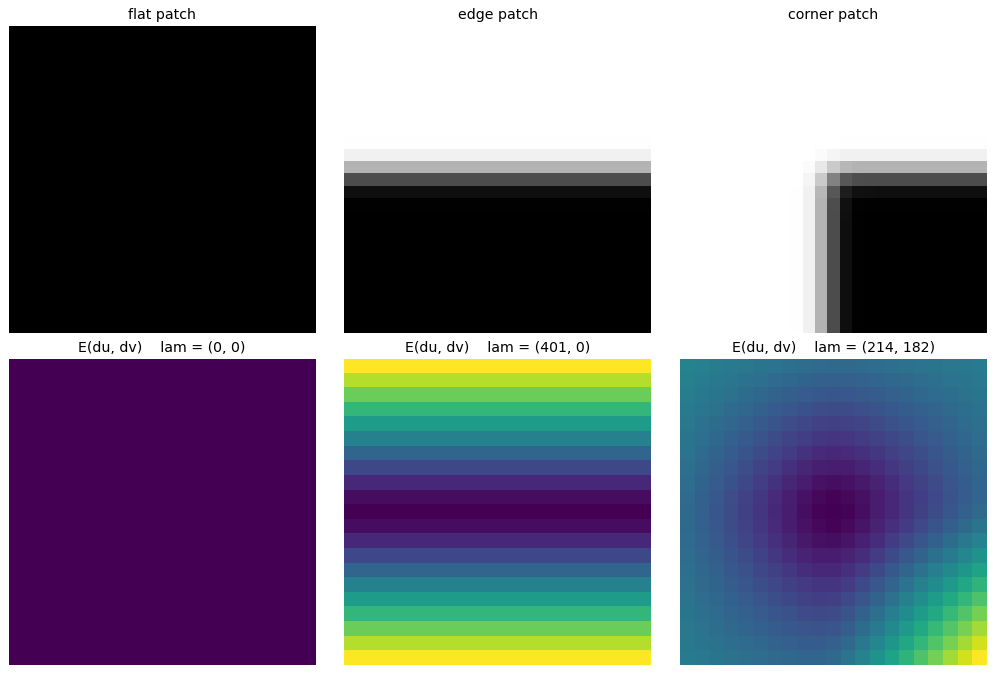

In [6]:
sq = np.ones((200, 200)); sq[60:140, 60:140] = 0.0      # black square -> a corner at (60, 60)
sq = ndi.gaussian_filter(sq, 1)
Ix, Iy = ndi.sobel(sq, axis=1), ndi.sobel(sq, axis=0)
h, S = 12, 10
patches = {'flat': (30, 30), 'edge': (60, 100), 'corner': (60, 60)}

def E_surface(r, c):                        # SSD error over a grid of shifts (du, dv)
    p0 = sq[r-h:r+h+1, c-h:c+h+1]
    E = np.zeros((2*S+1, 2*S+1))
    for i, dv in enumerate(range(-S, S+1)):
        for j, du in enumerate(range(-S, S+1)):
            ps = sq[r-h+dv:r+h+1+dv, c-h+du:c+h+1+du]
            E[i, j] = np.sum((ps - p0)**2)
    return E

def A_matrix(r, c):                         # second moment matrix over the window
    sx, sy = Ix[r-h:r+h+1, c-h:c+h+1], Iy[r-h:r+h+1, c-h:c+h+1]
    return np.array([[np.sum(sx*sx), np.sum(sx*sy)],
                     [np.sum(sx*sy), np.sum(sy*sy)]])

fig, ax = plt.subplots(2, 3, figsize=(12, 8))
for j, (name, (r, c)) in enumerate(patches.items()):
    lam = np.linalg.eigvalsh(A_matrix(r, c))[::-1]
    show(ax[0, j], sq[r-h:r+h+1, c-h:c+h+1], f'{name} patch')
    ax[1, j].imshow(E_surface(r, c), cmap='viridis')
    ax[1, j].set_title(f'E(du, dv)    lam = ({lam[0]:.0f}, {lam[1]:.0f})'); ax[1, j].axis('off')
plt.tight_layout(); plt.show()

## 5. Eigenvalues classify the window

Diagonalizing the second moment matrix,

$$
A = U \begin{bmatrix} \lambda_1 & 0 \\ 0 & \lambda_2 \end{bmatrix} U^\top,
$$

the eigenvalues measure intensity change along the two principal directions:

- $\lambda_1, \lambda_2$ both small $\rightarrow$ **flat**
- one large, one small $\rightarrow$ **edge**
- both large $\rightarrow$ **corner**

For a symmetric $A = \begin{bmatrix} a & b \\ b & c \end{bmatrix}$ the eigenvalues have a closed form, which makes a per-pixel map cheap:

$$
\lambda_{1,2} = \frac{a + c}{2} \pm \sqrt{\left( \frac{a - c}{2} \right)^2 + b^2}.
$$

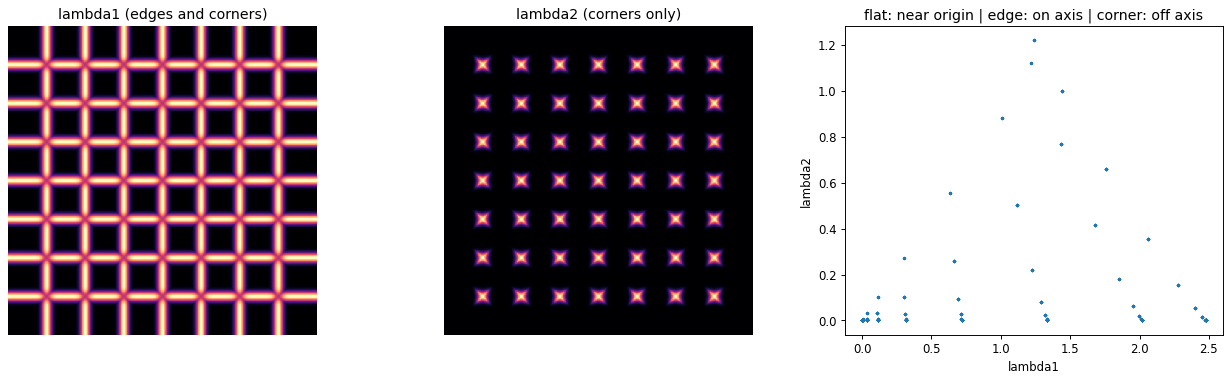

In [7]:
chk = ndi.gaussian_filter(load_gray(data.checkerboard()), 1)
Ix, Iy = ndi.sobel(chk, axis=1), ndi.sobel(chk, axis=0)
a, b, c, lam1, lam2 = second_moment_eigs(Ix, Iy, sigma_w=2)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
show(ax[0], lam1, 'lambda1 (edges and corners)', cmap='magma')
show(ax[1], lam2, 'lambda2 (corners only)', cmap='magma')
sub = (slice(None, None, 3), slice(None, None, 3))   # subsample for the scatter
ax[2].scatter(lam1[sub].ravel(), lam2[sub].ravel(), s=3, alpha=0.2)
ax[2].set_xlabel('lambda1'); ax[2].set_ylabel('lambda2')
ax[2].set_title('flat: near origin | edge: on axis | corner: off axis')
plt.tight_layout(); plt.show()

## 6. The Harris corner detector

Computing eigenvalues at every pixel is avoidable. Harris (1988) uses a response built from the determinant and trace, which need only the entries of $A$:

$$
M_c = \lambda_1 \lambda_2 - \kappa (\lambda_1 + \lambda_2)^2 = \det(A) - \kappa \, \mathrm{trace}^2(A),
\qquad \kappa \in [0.04, 0.06].
$$

$M_c$ is large and positive only when both eigenvalues are large. The full detector:

1. Compute gradients $I_x, I_y$.
2. Form $I_x^2, I_y^2, I_x I_y$ and smooth each with $w$ to build $A$ at every pixel.
3. Compute the response $M_c = \det(A) - \kappa \, \mathrm{trace}^2(A)$.
4. Threshold $M_c$.
5. Keep local maxima (non-maximum suppression).

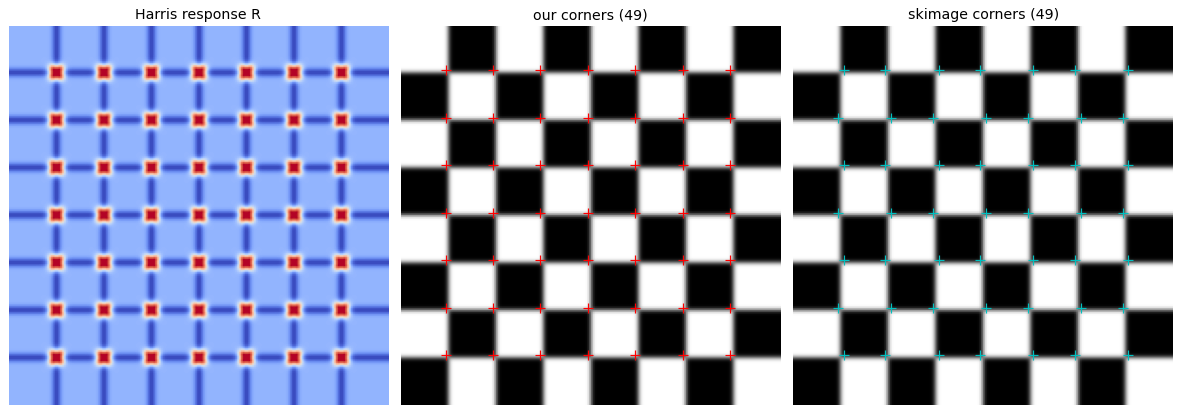

In [8]:
def harris_response(im, sigma=1, sigma_w=2, kappa=0.05):
    g = ndi.gaussian_filter(im, sigma)
    Ix, Iy = ndi.sobel(g, axis=1), ndi.sobel(g, axis=0)
    a, b, c, _, _ = second_moment_eigs(Ix, Iy, sigma_w)
    det, trace = a*c - b*b, a + c
    return det - kappa * trace**2

def harris_corners(im, threshold_rel=0.05, **kw):
    R = harris_response(im, **kw)
    pts = peak_local_max(R, min_distance=8, threshold_rel=threshold_rel, exclude_border=8)
    return R, pts

chk = ndi.gaussian_filter(load_gray(data.checkerboard()), 1)
R, pts = harris_corners(chk)
ref = corner_peaks(corner_harris(chk), min_distance=8, threshold_rel=0.05, exclude_border=8)

fig, ax = plt.subplots(1, 3, figsize=(14, 4.8))
show(ax[0], R, 'Harris response R', cmap='coolwarm')
show(ax[1], chk, f'our corners ({len(pts)})');   ax[1].plot(pts[:, 1], pts[:, 0], 'r+', ms=9)
show(ax[2], chk, f'skimage corners ({len(ref)})'); ax[2].plot(ref[:, 1], ref[:, 0], 'c+', ms=9)
plt.tight_layout(); plt.show()

.../site-packages/skimage/color/colorconv.py:984: RuntimeWarning: divide by zero encountered in matmul
  return rgb @ coeffs
.../site-packages/skimage/color/colorconv.py:984: RuntimeWarning: overflow encountered in matmul
  return rgb @ coeffs
.../site-packages/skimage/color/colorconv.py:984: RuntimeWarning: invalid value encountered in matmul
  return rgb @ coeffs


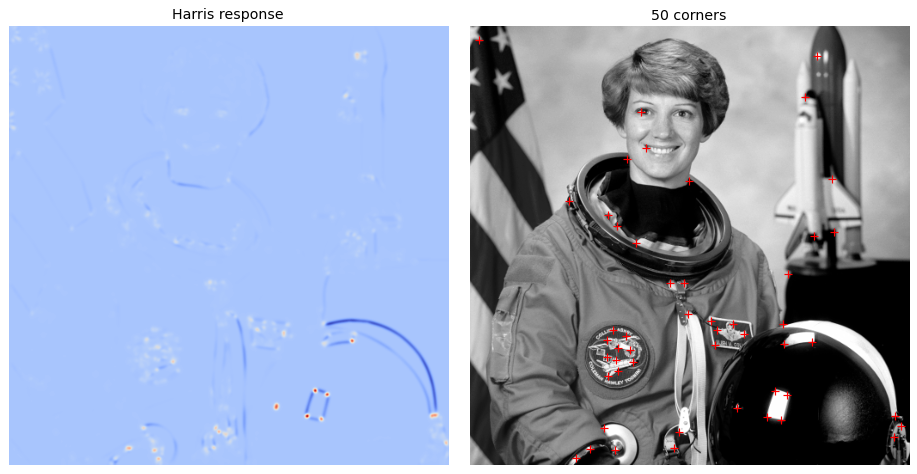

In [9]:
# the same detector on a natural image
astro = load_gray(data.astronaut())
Ra, pa = harris_corners(astro, threshold_rel=0.08)

fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
show(ax[0], Ra, 'Harris response', cmap='coolwarm')
show(ax[1], astro, f'{len(pa)} corners'); ax[1].plot(pa[:, 1], pa[:, 0], 'r+', ms=7)
plt.tight_layout(); plt.show()

## 7. Cornerness measures and variants

The same matrix $A$ admits several cornerness scores, all functions of $\lambda_0, \lambda_1$:

$$
\text{Harris-Stephens: } \det(A) - \alpha \, \mathrm{trace}^2(A)
\qquad
\text{Triggs: } \lambda_0 - \alpha \lambda_1
\qquad
\text{Brown (harmonic mean): } \frac{\det(A)}{\mathrm{trace}(A)} = \frac{\lambda_0 \lambda_1}{\lambda_0 + \lambda_1}.
$$

The harmonic mean is smoother near $\lambda_0 \approx \lambda_1$ and needs no free parameter $\kappa$. The two response maps below agree on corners but differ in how sharply they fall off.

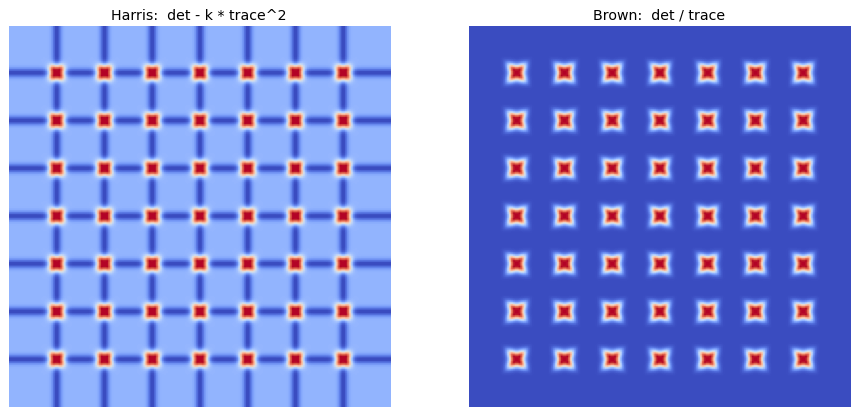

In [10]:
def harmonic_mean_response(im, sigma=1, sigma_w=2, eps=1e-6):
    g = ndi.gaussian_filter(im, sigma)
    Ix, Iy = ndi.sobel(g, axis=1), ndi.sobel(g, axis=0)
    a, b, c, _, _ = second_moment_eigs(Ix, Iy, sigma_w)
    det, trace = a*c - b*b, a + c
    return det / (trace + eps)

chk = ndi.gaussian_filter(load_gray(data.checkerboard()), 1)
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
show(ax[0], harris_response(chk),         'Harris:  det - k * trace^2', cmap='coolwarm')
show(ax[1], harmonic_mean_response(chk),  'Brown:  det / trace',        cmap='coolwarm')
plt.tight_layout(); plt.show()

## 8. Properties: rotation and scale

The response depends on $A$, which behaves predictably under image transforms:

- **Rotation**: rotating the image rotates the eigenvectors of $A$ but leaves the eigenvalues unchanged, so relative cornerness is preserved. Harris is **rotation invariant**.
- **Photometric**: only derivatives enter $A$, so a brightness shift $I \rightarrow I + b$ has no effect; a contrast scale $I \rightarrow a I$ scales the response, so it is only **partially** invariant.
- **Scale**: a structure that is a corner under a small window becomes an edge under a large one. Harris is **not scale invariant**; the detected set changes with image scale.

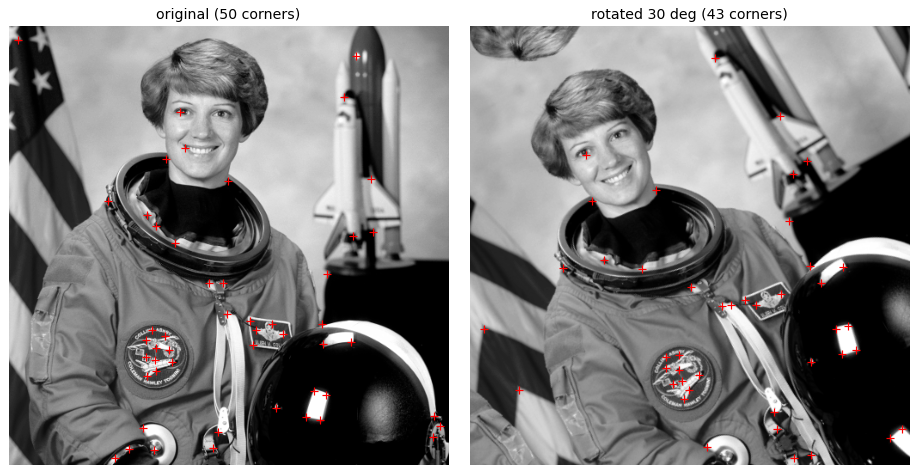

In [11]:
# rotation: corners are found at corresponding points
astro = load_gray(data.astronaut())
_, p0 = harris_corners(astro, threshold_rel=0.08)
rot   = rotate(astro, 30, resize=False, mode='reflect')
_, p1 = harris_corners(rot, threshold_rel=0.08)

fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
show(ax[0], astro, f'original ({len(p0)} corners)'); ax[0].plot(p0[:, 1], p0[:, 0], 'r+', ms=6)
show(ax[1], rot,   f'rotated 30 deg ({len(p1)} corners)'); ax[1].plot(p1[:, 1], p1[:, 0], 'r+', ms=6)
plt.tight_layout(); plt.show()

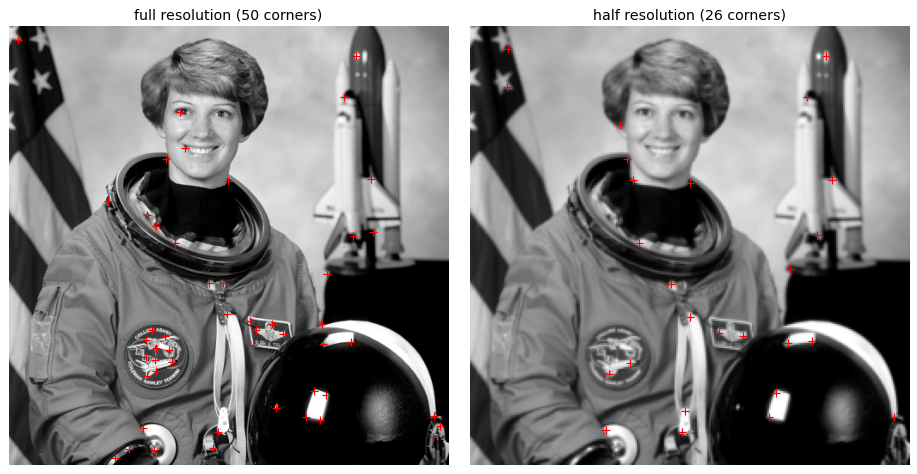

In [12]:
# scale: the detected corner set is not preserved across resolutions
full = load_gray(data.astronaut())
half = ndi.gaussian_filter(full, 1)[::2, ::2]
_, pf = harris_corners(full, threshold_rel=0.08)
_, ph = harris_corners(half, threshold_rel=0.08)

fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
show(ax[0], full, f'full resolution ({len(pf)} corners)'); ax[0].plot(pf[:, 1], pf[:, 0], 'r+', ms=6)
show(ax[1], half, f'half resolution ({len(ph)} corners)'); ax[1].plot(ph[:, 1], ph[:, 0], 'r+', ms=6)
plt.tight_layout(); plt.show()

## 9. Explore and verify

Two claims from this lecture are directly testable: that the Harris detector is invariant
to rotation but **not** to scale, and that the eigenvalues of the second moment matrix
separate flat, edge and corner windows. We test both, then sweep the detector's knobs.

In [13]:
# Verify the invariance claims.
from skimage import transform
import scipy.ndimage as ndi

im = util.img_as_float(data.checkerboard())

# harris_corners returns (R, pts).
_, pts0  = harris_corners(im, threshold_rel=0.1)
_, pts90 = harris_corners(np.rot90(im), threshold_rel=0.1)
assert len(pts0) == len(pts90), f'rotation changed the corner count: {len(pts0)} vs {len(pts90)}'

big = transform.rescale(im, 2.0, anti_aliasing=True)
_, pts2x = harris_corners(big, threshold_rel=0.1)

# Eigenvalues classify the window. second_moment_eigs returns (a, b, c, lam1, lam2).
print('  window     lambda_max   lambda_min   expected')
for name, patch, expect in [('flat',   np.ones((40, 40)) * 0.5,               'both small'),
                            ('edge',   np.r_[np.zeros((40, 20)), np.ones((40, 20))].reshape(40, 40).T, 'one large'),
                            ('corner', np.pad(np.ones((20, 20)), ((20, 0), (20, 0))), 'both large')]:
    gx, gy = ndi.sobel(patch, axis=1), ndi.sobel(patch, axis=0)
    _, _, _, l1, l2 = second_moment_eigs(gx, gy, 2.0)
    print(f'  {name:8s} {l1.max():10.3f} {l2.max():12.3f}   {expect}')

print(f'\nrotation by 90 degrees: {len(pts0)} corners -> {len(pts90)} corners (invariant)')
print(f'scaling by 2x         : {len(pts0)} corners -> {len(pts2x)} corners (NOT invariant)')

  window     lambda_max   lambda_min   expected
  flat          0.000        0.000   both small
  edge          6.008        0.000   one large
  corner        6.008        2.935   both large

rotation by 90 degrees: 49 corners -> 49 corners (invariant)
scaling by 2x         : 49 corners -> 49 corners (NOT invariant)


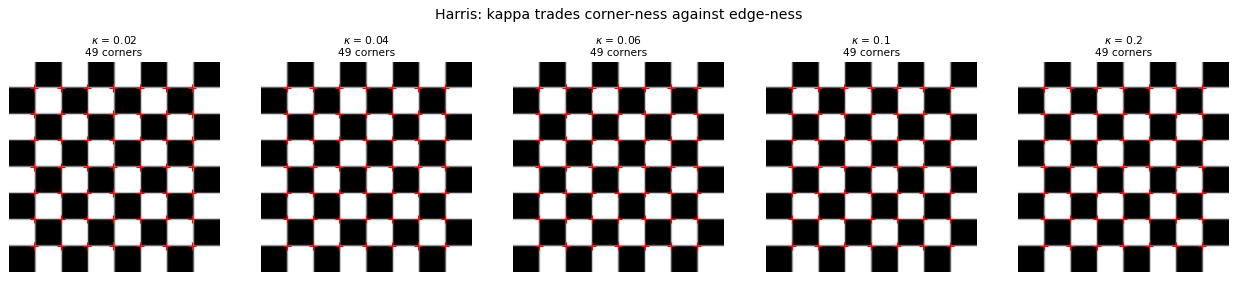

In [14]:
# Static sweep: the sensitivity parameter kappa.
fig, ax = plt.subplots(1, 5, figsize=(15, 3.2))
for a, kap in zip(ax, [0.02, 0.04, 0.06, 0.10, 0.20]):
    _, pts = harris_corners(im, threshold_rel=0.1, kappa=kap)
    a.imshow(im, cmap='gray'); a.set_axis_off()
    if len(pts): a.plot(pts[:, 1], pts[:, 0], 'r+', ms=6)
    a.set_title(f'$\kappa$ = {kap}\n{len(pts)} corners', fontsize=9)
fig.suptitle('Harris: kappa trades corner-ness against edge-ness', y=1.02)
plt.tight_layout(); plt.show()

Now the same thing under your control. Drag the slider and watch what changes.

In [15]:
# Live: kappa and the detection threshold together.
from ipywidgets import interact, FloatSlider

def harris(kappa=0.04, threshold_rel=0.10):
    _, pts = harris_corners(im, threshold_rel=threshold_rel, kappa=kappa)
    fig, a = plt.subplots(figsize=(4.6, 4.6))
    a.imshow(im, cmap='gray'); a.set_axis_off()
    if len(pts): a.plot(pts[:, 1], pts[:, 0], 'r+', ms=7)
    a.set_title(f'$\kappa$={kappa:.3f}, threshold={threshold_rel:.2f}  ->  {len(pts)} corners')
    plt.show()

interact(harris,
         kappa=FloatSlider(min=0.01, max=0.25, step=0.01, value=0.04),
         threshold_rel=FloatSlider(min=0.02, max=0.50, step=0.02, value=0.10));

interactive(children=(FloatSlider(value=0.04, description='kappa', max=0.25, min=0.01, step=0.01), FloatSlider…

---

## Key takeaways

| Concept | Key takeaway |
|---|---|
| **Second moment matrix** | Eigen-analysis of a local $2 \times 2$ matrix recurs for lines, blobs, and corners |
| **Line segments** | Orientation from the larger eigenvector; straightness from $\lambda_2 / \lambda_1$ |
| **Laplacian** | $\nabla^2 f$ has the $3 \times 3$ kernel $[\,0,1,0;\,1,-4,1;\,0,1,0\,]$ |
| **LoG** | $\nabla^2(f * g)$ smooths then takes the Laplacian; less noise sensitive |
| **Blob detection** | LoG is circularly symmetric; a blob of radius $r$ peaks at $\sigma \approx r / \sqrt{2}$ across scale |
| **Autocorrelation** | $E_{AC}(\Delta u) \approx \Delta u^\top A \, \Delta u$ with $A = w * [\,I_x^2, I_x I_y;\, I_x I_y, I_y^2\,]$ |
| **Eigenvalues** | Both small flat, one large edge, both large corner |
| **Harris** | $M_c = \det(A) - \kappa \, \mathrm{trace}^2(A)$ avoids an explicit eigen-decomposition |
| **Variants** | Triggs $\lambda_0 - \alpha \lambda_1$; Brown harmonic mean $\det(A) / \mathrm{trace}(A)$ |
| **Invariance** | Rotation invariant, partially photometric invariant, not scale invariant |

**Reading:** Szeliski, *Computer Vision: Algorithms and Applications*, Ch. 2; Forsyth and Ponce, *Computer Vision: A Modern Approach*, Ch. 5.

**References:** C. Harris and M. Stephens (1988); B. Triggs (2004); M. Brown, R. Szeliski, S. Winder (2005). Slide sources: K. Grauman, R. Urtasun, S. Seitz, N. Snavely, S. Lazebnik, D. Hoiem.

## Exercises

1. **Rotation yes, scale no.** Rotate a patch and confirm the Harris response is stable; then rescale it and show the response is not. Explain what breaks, using the fixed window size.

2. **Cornerness measures compared.** Sweep Harris's $k$ and compare the detections against the Shi-Tomasi $\min(\lambda_1, \lambda_2)$ measure. Where do the two disagree?

3. **Verify the blob scale law.** For synthetic disks of several radii, find the $\sigma$ that maximises the scale-normalized LoG and check it against $\sigma^\star \approx r/\sqrt{2}$.

4. **Read the eigenvalues.** For a flat patch, an edge and a corner, print $(\lambda_1, \lambda_2)$ and classify each by hand. Confirm your labels match the detector's output.